# Constrained-dealer model — **PARK**

**Paper:** §4 partial-equilibrium model (PDF pp. 23–30; Eqs 8–20) · **NOTES:** [`NOTES.md`](NOTES.md)  
**Status:** `park` — qualitative crypto-calibrated DGP only; not a trading engine.

Intuition: higher constraint intensity η raises effective spreads / weakens liquidity supply; PIM-like gaps widen when dealers cannot absorb inventory.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path(os.environ.get("ARES_MICROSTRUCTURE") or (Path.home() / "srv" / "ares-microstructure")) / "research" / "books" / "cd_me"
OUT = BOOK / "out"
SCRIPTS = BOOK / "scripts"
ROOT = BOOK.parents[2]  # ares-microstructure repo root (research.lib absolute imports)
sys.path.insert(0, str(SCRIPTS))
sys.path.insert(0, str(ROOT))
from _nb_common import (
    load_json, expand_pim_hourly, expand_dcm_hourly, day_summary_table, SIGNAL_BOARD,
    load_kraken_inventory, kraken_mode_for_day,
)
from certified_panel import load_certified, primary_days, spot_l2_days
from research.lib import cdme  # noqa: E402

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

def show_pngs(fig_dir: Path, pattern="*.png"):
    if not fig_dir.is_dir():
        print("no figs dir", fig_dir)
        return
    for p in sorted(fig_dir.glob(pattern)):
        display(Markdown(f"**{p.name}** — `{p.relative_to(BOOK)}`"))
        display(Image(filename=str(p)))

def print_board(rows=None):
    rows = rows or SIGNAL_BOARD
    print(f"{'id':34s} {'gate':6s} note")
    print("-" * 88)
    for i, g, n in rows:
        print(f"{i:34s} {g:6s} {n}")

PASS2 = OUT / "pass2"
KR_INV = load_kraken_inventory(BOOK)
CERT = load_certified()
PRIMARY = primary_days(CERT)
SPOT = spot_l2_days(CERT)
print("BOOK", BOOK)
print("certified primary n=", len(PRIMARY), PRIMARY)
print("spot_l2 subpanel n=", len(SPOT), SPOT)
print("pass2 present", PASS2.is_dir(), "falsifiers", (PASS2 / "pass2_falsifiers.json").is_file())
print("trade_synth QUARANTINED — never primary")


BOOK /home/dev/srv/ares-microstructure/research/books/cd_me
certified primary n= 9 ['2026-09-14', '2026-09-15', '2026-09-16', '2026-09-17', '2026-09-18', '2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
spot_l2 subpanel n= 4 ['2026-09-25', '2026-09-26', '2026-09-27', '2026-10-01']
pass2 present True falsifiers True
trade_synth QUARANTINED — never primary


## Toy simulation — constraint intensity vs clearing spread


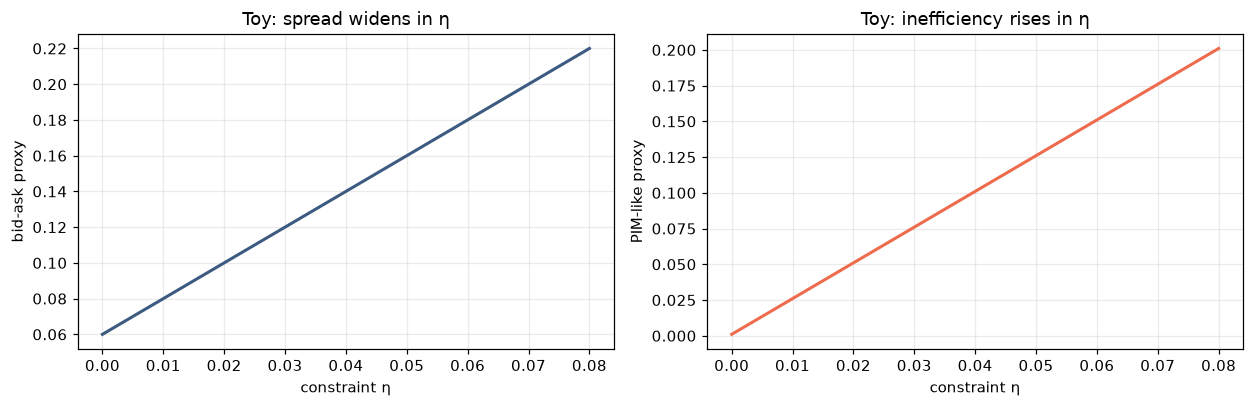

Qualitative match only — park quantitative DGP until crypto-calibrated params exist


In [2]:

# Extremely reduced toy (not paper Prop 1 proof): mean-variance dealer with funding wedge η.
# q = (a - η - e) / (ρ σ²) for long side; spread proxy ↑ in η.

rho, sigma2, e = 1.0, 0.02, 0.0
demand = 1.5  # exogenous imbalance to clear
etas = np.linspace(0.0, 0.08, 40)
spreads = []
pim_proxy = []
for eta in etas:
    # ask needed to induce supply q=demand: a = e + η + q ρ σ²
    a = e + eta + demand * rho * sigma2
    b = e - eta - demand * rho * sigma2
    spr = a - b
    spreads.append(spr)
    # naive VLOOP-like residual if constrained mid stuck: grow with η
    pim_proxy.append(0.001 + 2.5 * eta)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax = axes[0]
ax.plot(etas, spreads, color="#3d5a80", lw=2)
ax.set_xlabel("constraint η"); ax.set_ylabel("bid-ask proxy"); ax.set_title("Toy: spread widens in η")
ax = axes[1]
ax.plot(etas, pim_proxy, color="#ee6c4d", lw=2)
ax.set_xlabel("constraint η"); ax.set_ylabel("PIM-like proxy"); ax.set_title("Toy: inefficiency rises in η")
plt.tight_layout(); plt.show()
print("Qualitative match only — park quantitative DGP until crypto-calibrated params exist")


## Signal board


In [3]:

print_board([
    ("disc.constrained_dealer_dgp", "Park", "toy qualitative; no Promote path"),
])
print("Falsifier status: N/A while parked")


id                                 gate   note
----------------------------------------------------------------------------------------
disc.constrained_dealer_dgp        Park   toy qualitative; no Promote path
Falsifier status: N/A while parked
